In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import os

from aquacrop_slovenia import config

Failed to reload module 'pandas.errors' from file 'C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\pandas\errors\__init__.py'
Traceback (most recent call last):
  File "C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 451, in update_generic
    update(a, b)
    ~~~~~~^^^^^^
  File "C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 384, in update_class
    old_obj = getattr(old, key)
AttributeError: type object

In [21]:
temp = pd.read_csv(config.RAW_WEATHER_DIR / "station_355_temperature.csv", sep=";")
precip = pd.read_csv(config.RAW_WEATHER_DIR / "station_355_precipitation.csv", sep=";")
et = pd.read_csv(config.RAW_WEATHER_DIR / "station_355_evapotranspiration.csv", sep=";")

In [22]:
temp["datum"] = pd.to_datetime(temp.datum, format="%m.%d.%Y")
precip["datum"] = pd.to_datetime(precip.datum, format="%m.%d.%Y")
et["datum"] = pd.to_datetime(et.datum, format="%m.%d.%Y")

In [23]:
temp

,postaja,datum,tpov,tmin,tmax
0,355,1993-01-01,-5.1,-6.6,-2.2
1,355,1993-01-02,-7.3,-9.3,-6.4
2,355,1993-01-03,-6.7,-9.0,-5.2
3,355,1993-01-04,-8.6,-12.3,-3.3
4,355,1993-01-05,-11.8,-15.8,-4.9
...,...,...,...,...,...
11317,355,2023-12-27,3.1,-1.5,10.9
11318,355,2023-12-28,2.1,-2.2,11.3
11319,355,2023-12-29,2.3,-2.3,11.6
11320,355,2023-12-30,1.7,-1.8,10.5


In [24]:
temp.describe()

,postaja,datum,tpov,tmin,tmax
count,11322.0,11322,11322.000000,11322.000000,11322.000000
mean,355.0,2008-07-01 12:00:00,10.718822,5.804699,16.293658
min,355.0,1993-01-01 00:00:00,-16.900000,-23.700000,-11.000000
25%,355.0,2000-10-01 06:00:00,3.900000,-0.400000,8.800000
50%,355.0,2008-07-01 12:00:00,11.300000,6.200000,17.200000
75%,355.0,2016-03-31 18:00:00,17.600000,12.300000,24.100000
max,355.0,2023-12-31 00:00:00,30.100000,21.900000,39.700000
std,0.0,NaN,8.359365,7.661643,9.625335


In [25]:
precip

,postaja,datum,pad
0,355,1993-01-01,0.0
1,355,1993-01-02,0.0
2,355,1993-01-03,0.0
3,355,1993-01-04,1.4
4,355,1993-01-05,0.6
...,...,...,...
11317,355,2023-12-27,0.0
11318,355,2023-12-28,0.0
11319,355,2023-12-29,0.0
11320,355,2023-12-30,0.0


In [26]:
precip.describe()

,postaja,datum,pad
count,11322.0,11322,11322.000000
mean,355.0,2008-07-01 12:00:00,2.244701
min,355.0,1993-01-01 00:00:00,0.000000
25%,355.0,2000-10-01 06:00:00,0.000000
50%,355.0,2008-07-01 12:00:00,0.000000
75%,355.0,2016-03-31 18:00:00,0.800000
max,355.0,2023-12-31 00:00:00,98.100000
std,0.0,NaN,6.161439


In [27]:
et

,postaja,datum,etp
0,355,1993-01-01,0.8
1,355,1993-01-02,0.9
2,355,1993-01-03,0.7
3,355,1993-01-04,0.3
4,355,1993-01-05,0.0
...,...,...,...
11317,355,2023-12-27,0.2
11318,355,2023-12-28,0.3
11319,355,2023-12-29,0.2
11320,355,2023-12-30,0.4


In [28]:
et.describe()

,postaja,datum,etp
count,11322.0,11322,11320.000000
mean,355.0,2008-07-01 12:00:00,2.196272
min,355.0,1993-01-01 00:00:00,0.000000
25%,355.0,2000-10-01 06:00:00,0.600000
50%,355.0,2008-07-01 12:00:00,1.750000
75%,355.0,2016-03-31 18:00:00,3.600000
max,355.0,2023-12-31 00:00:00,8.400000
std,0.0,NaN,1.717640


In [29]:
meteo_data = pd.merge(pd.merge(temp, precip, on="datum", how="outer"), et, on="datum", how="outer")
meteo_data.drop(["postaja_x", "postaja_y", "postaja"], axis=1, inplace=True)

In [30]:
meteo_data

,datum,tpov,tmin,tmax,pad,etp
0,1993-01-01,-5.1,-6.6,-2.2,0.0,0.8
1,1993-01-02,-7.3,-9.3,-6.4,0.0,0.9
2,1993-01-03,-6.7,-9.0,-5.2,0.0,0.7
3,1993-01-04,-8.6,-12.3,-3.3,1.4,0.3
4,1993-01-05,-11.8,-15.8,-4.9,0.6,0.0
...,...,...,...,...,...,...
11317,2023-12-27,3.1,-1.5,10.9,0.0,0.2
11318,2023-12-28,2.1,-2.2,11.3,0.0,0.3
11319,2023-12-29,2.3,-2.3,11.6,0.0,0.2
11320,2023-12-30,1.7,-1.8,10.5,0.0,0.4


In [31]:
meteo_data.describe()

,datum,tpov,tmin,tmax,pad,etp
count,11322,11322.000000,11322.000000,11322.000000,11322.000000,11320.000000
mean,2008-07-01 12:00:00,10.718822,5.804699,16.293658,2.244701,2.196272
min,1993-01-01 00:00:00,-16.900000,-23.700000,-11.000000,0.000000,0.000000
25%,2000-10-01 06:00:00,3.900000,-0.400000,8.800000,0.000000,0.600000
50%,2008-07-01 12:00:00,11.300000,6.200000,17.200000,0.000000,1.750000
75%,2016-03-31 18:00:00,17.600000,12.300000,24.100000,0.800000,3.600000
max,2023-12-31 00:00:00,30.100000,21.900000,39.700000,98.100000,8.400000
std,NaN,8.359365,7.661643,9.625335,6.161439,1.717640


## Visualize data

<Axes: xlabel='datum'>

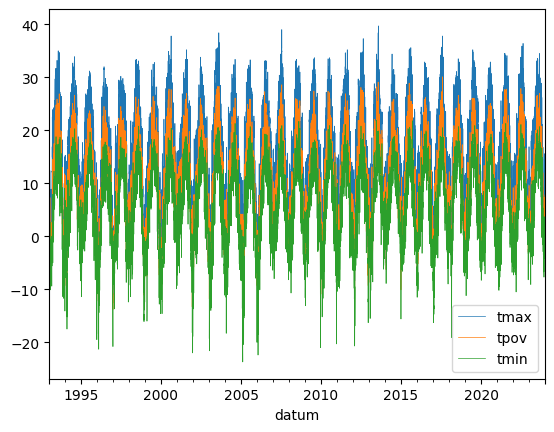

In [32]:
meteo_data.plot(x="datum", y=["tmax", "tpov", "tmin"], linewidth=0.5)

<Axes: xlabel='datum'>

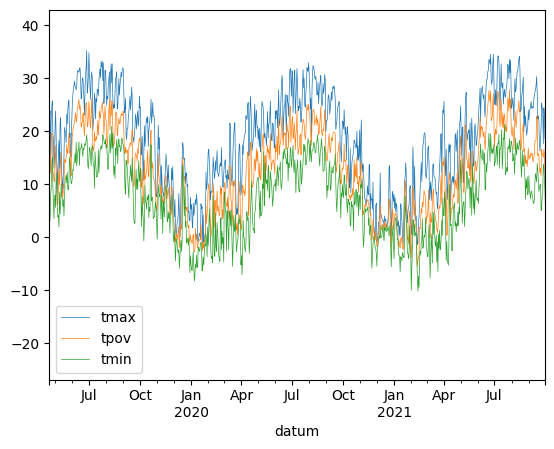

In [35]:
meteo_data.plot(x="datum", y=["tmax", "tpov", "tmin"], linewidth=0.5, xlim=("2019-04-20","2021-09-30"))

<Axes: xlabel='datum'>

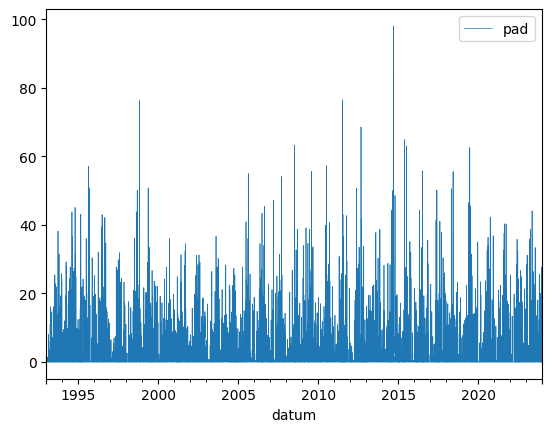

In [36]:
meteo_data.plot(x="datum", y=["pad"], linewidth=0.5)

<Axes: xlabel='datum'>

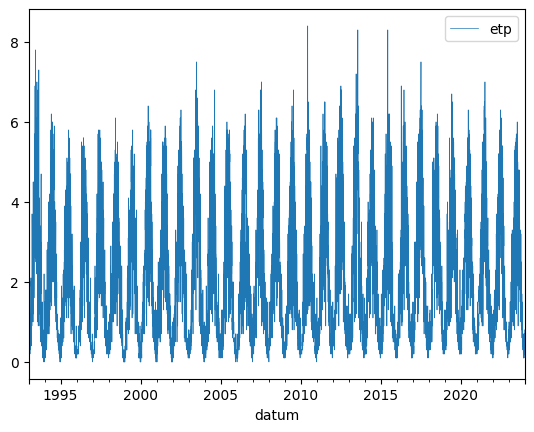

In [37]:
meteo_data.plot(x="datum", y=["etp"], linewidth=0.5)

<Axes: xlabel='datum'>

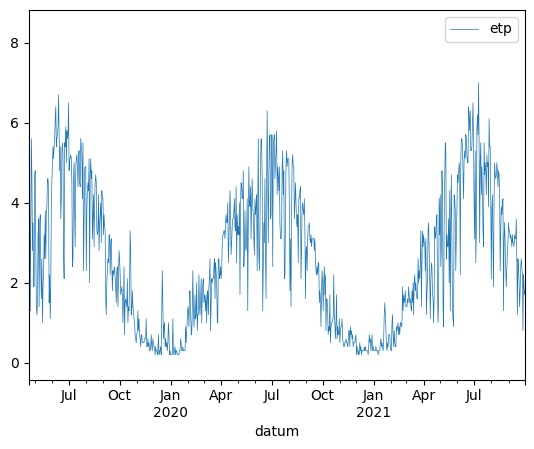

In [38]:
meteo_data.plot(x="datum", y=["etp"], linewidth=0.5, xlim=("2019-04-20","2021-09-30"))

## Weather statistics

In [39]:
climate_data = meteo_data.copy()
climate_data["Year"] = climate_data["datum"].dt.year
climate_data["Month"] = climate_data["datum"].dt.month
climate_data["Day"] = climate_data["datum"].dt.day
yearly_mean = climate_data.groupby('Year').mean()
yearly_sum = climate_data.groupby('Year').sum(numeric_only=True)
daily_mean = climate_data.groupby(['Month', 'Day']).mean()
daily_sum = climate_data.groupby("Year").cumsum(numeric_only=True)

In [40]:
yearly_mean[["tmin", "tpov", "tmax", "pad", "etp"]]

,tmin,tpov,tmax,pad,etp
Year,,,,,
1993,4.716712,9.864932,15.437534,1.883288,2.215616
1994,6.286575,11.129589,16.434247,2.710137,2.126849
1995,5.324932,9.988219,15.199178,2.531507,2.032329
1996,4.454372,8.845628,13.517213,2.802459,1.902732
1997,4.530411,9.477260,15.044658,1.895068,2.066849
1998,4.967123,10.010137,15.697808,2.298904,2.013699
1999,5.669863,10.280548,15.476986,2.116164,1.960000
2000,6.129235,11.462022,17.430328,1.777596,2.259563
2001,5.408767,10.399178,16.031781,1.761644,2.106575


<Axes: xlabel='Year'>

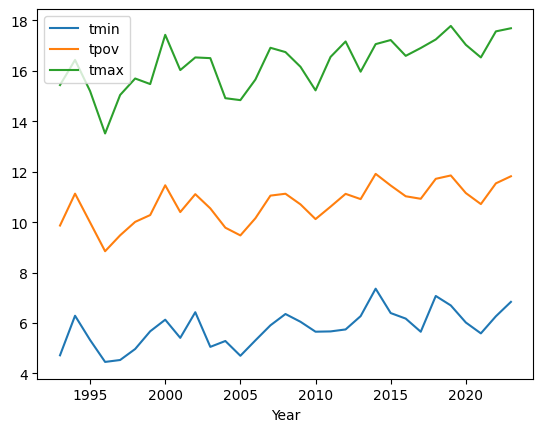

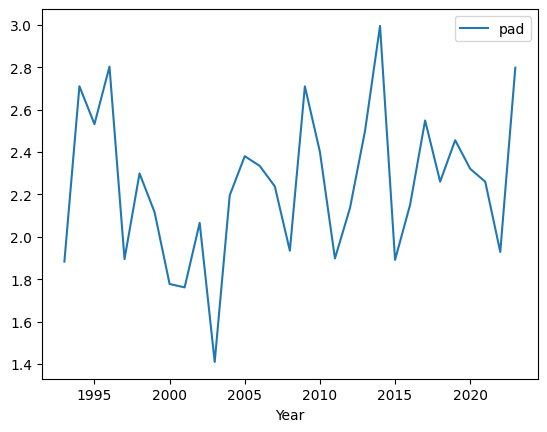

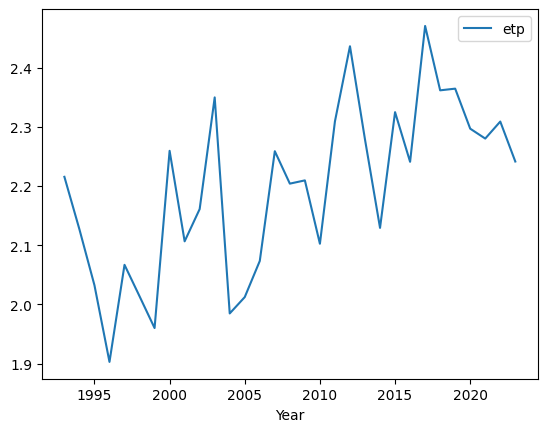

In [41]:
yearly_mean.plot(y=["tmin", "tpov", "tmax"])
yearly_mean.plot(y="pad")
yearly_mean.plot(y="etp")

Yearly sums of precipitation and ET

<Axes: xlabel='Year'>

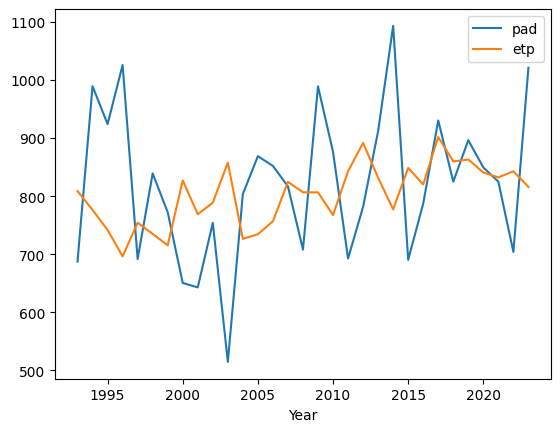

In [44]:
yearly_sum.plot(y=["pad", "etp"])

Climatology (whole period)

<Axes: xlabel='Month,Day'>

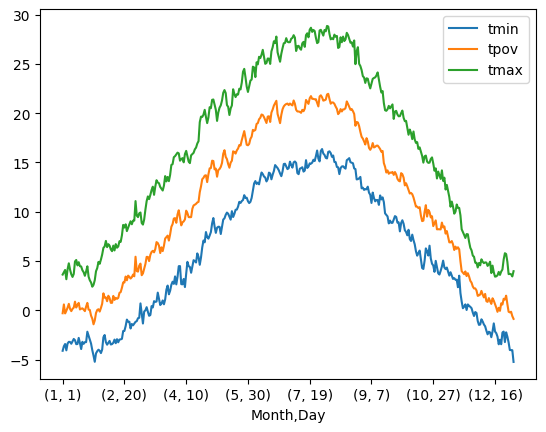

In [45]:
daily_mean.plot(y=["tmin", "tpov", "tmax"])

<Axes: >

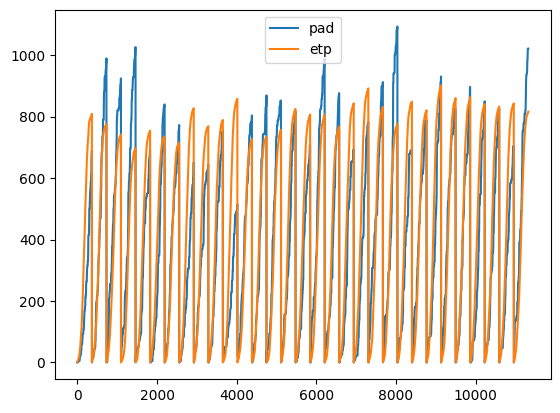

In [46]:
daily_sum.plot(y=["pad", "etp"])

## Missing data

In [47]:
for variable_name in ["tmin", "tpov", "tmax", "pad", "etp"]:
    print(variable_name)
    print(meteo_data[meteo_data[variable_name].isnull()])

tmin
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
tpov
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
tmax
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
pad
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
etp
           datum  tpov  tmin  tmax  pad  etp
9410  2018-10-07  15.6   9.9  20.1  0.1  NaN
11202 2023-09-03  19.1  14.4  25.5  0.0  NaN


In [48]:
meteo_data[meteo_data["etp"].isnull()]["datum"].tolist()

[Timestamp('2018-10-07 00:00:00'), Timestamp('2023-09-03 00:00:00')]

## Infill missing data

We TEMPORARILY!!! set all missing ET to 0

In [55]:
meteo_data.loc[meteo_data["etp"].isnull(), "etp"] = 0

## Export infilled data

In [57]:
pd.to_pickle(meteo_data, config.PROCESSED_WEATHER_DIR / "station_355.pkl")